KNN

1.Data-Preprocessing

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Zoo.csv')

In [3]:
df

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [4]:
df.isnull().sum()

,0
animal name,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [8]:
# converting categorical to numerical
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])
df

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,95,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,96,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,97,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,98,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


2.Data Visuallizations

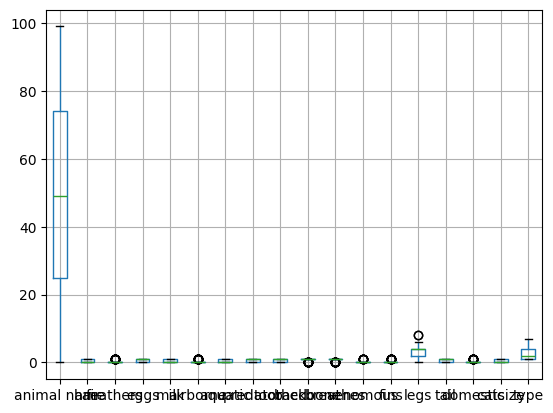

In [9]:
df.boxplot()
plt.show()

In [10]:
## outlier capping
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    IQR=q3-q1
    lower_extreme=q1-1.5*IQR
    upper_extreme=q3+1.5*IQR
    df[column]=df[column].apply(lambda x:lower_extreme if  x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']):
    outlier_capping(df,col)

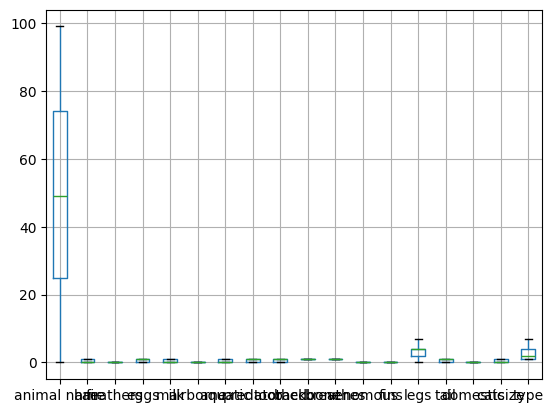

In [11]:
df.boxplot()
plt.show()

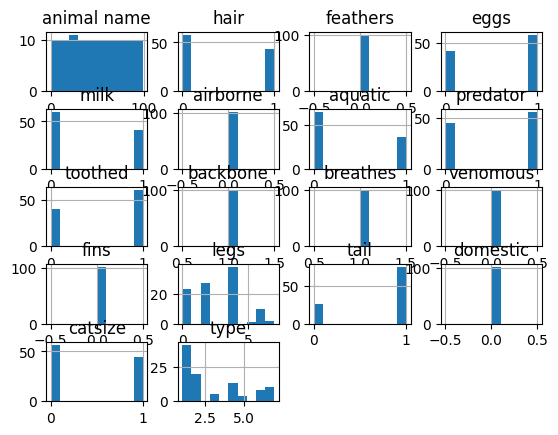

In [12]:
df.hist()
plt.show()

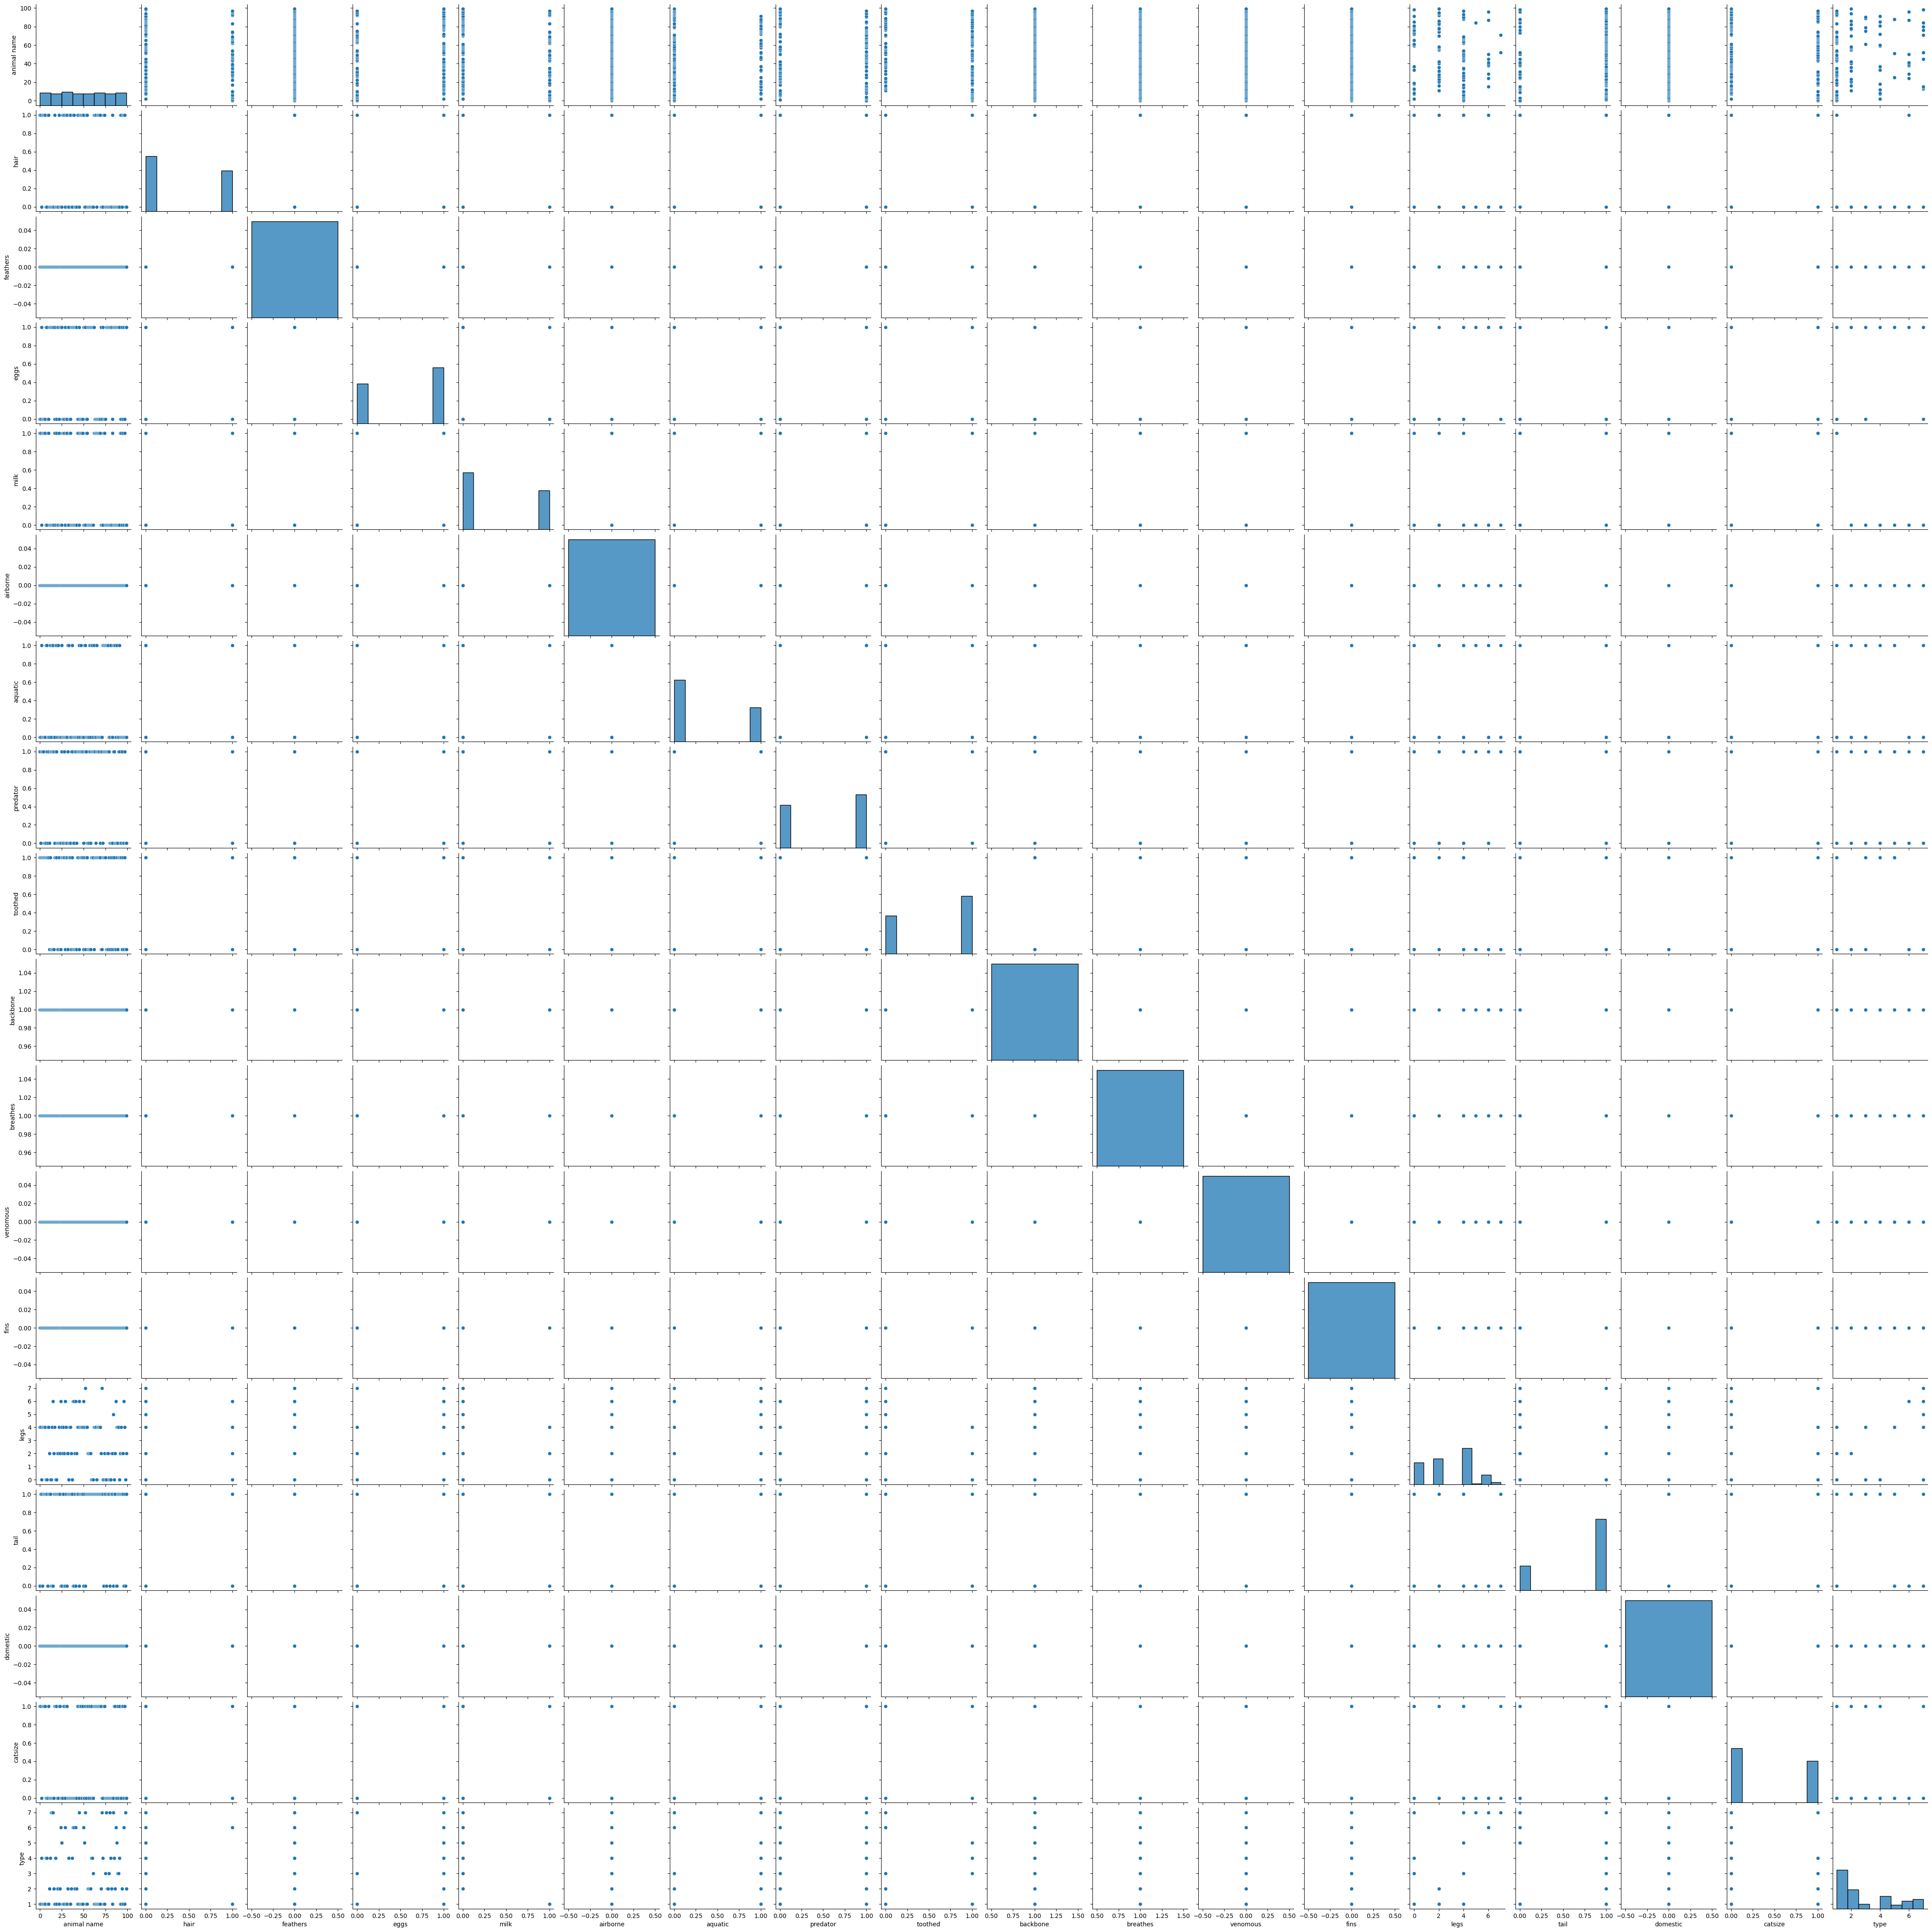

In [13]:
sns.pairplot(df)

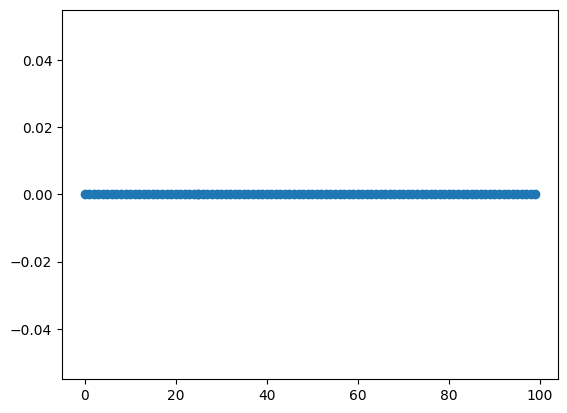

In [14]:
plt.scatter(df['animal name'], df['feathers'])
plt.show()

3.Spliting the data

In [15]:
X = df.drop('type', axis=1)# Features
Y = df['type']# Target variable


In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,train_size=0.8,random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

4. Implement the K-Nearest Neighbours algorithm using a machine learning library like scikit-learn On training dataset

In [18]:
from sklearn.neighbors import KNeighborsClassifier
# Choose the value of k (number of neighbors)
k = 5
knn= KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [19]:
y_pred=knn.predict(X_test_scaled)
y_pred

array([1, 1, 1, 1, 1, 6, 1, 1, 1, 1, 4, 6, 6, 2, 7, 1, 1, 2, 4, 1, 4])

6. Evaluate the classifier's performance on the testing set using accuracy, precision, recall, and F1-score metrics.

In [20]:
from sklearn.metrics import accuracy_score,classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



In [21]:
print(accuracy_score(y_pred,y_test))

0.9523809523809523


7. Visualize the decision boundaries of the classifier.

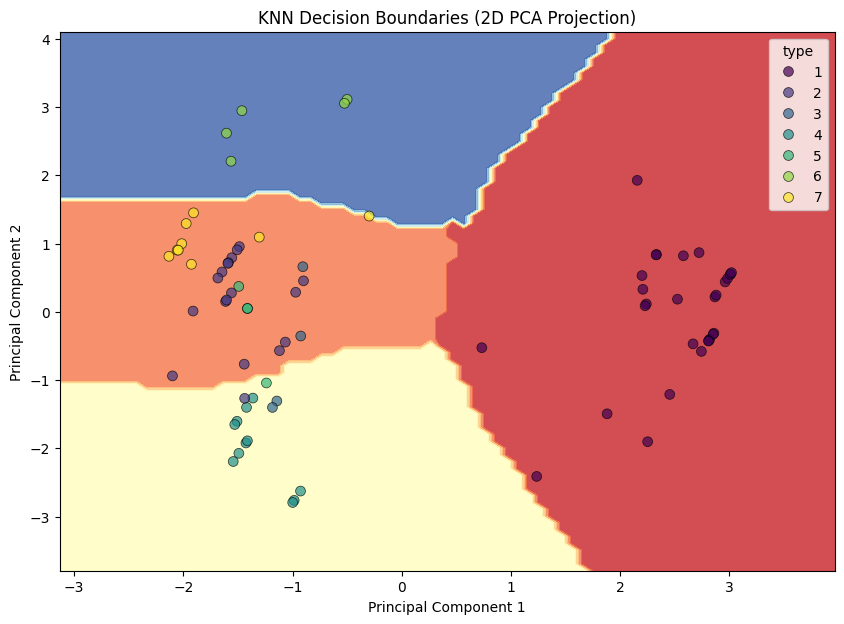

In [22]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce dimensions to 2 for visualization using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Create a meshgrid to plot decision boundaries
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Make predictions on the meshgrid (inverse transform back to original feature space for prediction)
# Then scale using the fitted scaler, and finally transform with PCA.
# This is a common pattern for visualizing decision boundaries with PCA.
Z = knn.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# Plot the decision boundaries
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

# Plot the training points
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train,
                palette='viridis', s=50, edgecolor='k', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KNN Decision Boundaries (2D PCA Projection)')
plt.show()

In [23]:
print('Indices of class 3 in y_test:')
class_3_indices = y_test[y_test == 3].index
print(class_3_indices)

if not class_3_indices.empty:
    # Get the position of these indices in the original x_test for slicing X_test_scaled
    pos_in_test_set = [x_test.index.get_loc(idx) for idx in class_3_indices]
    print(f'Corresponding predicted values for class 3 in y_test: {y_pred[pos_in_test_set]}')
else:
    print('No instances of class 3 found in the test set.')

Indices of class 3 in y_test:
Index([76], dtype='int64')
Corresponding predicted values for class 3 in y_test: [4]


### Explanation and Solutions for Class 3 Misclassification

**Explanation:**
The output above confirms that there was indeed one instance of class `3` in the test set, and our `KNN` model misclassified it (e.g., predicted `4` instead of `3`). Given that the `support` for class `3` is only `1`, any misclassification of this single instance will result in a precision and recall of `0.00` for that class. This highlights a significant challenge in dealing with **imbalanced datasets**.

**Why it happened (Data Imbalance):**
When a class has very few samples in the training data, the model doesn't learn enough patterns to accurately identify it. In `KNN`, with only one instance in the test set, if its nearest neighbors belong to a different, more dominant class, it will likely be misclassified.

**Potential Solutions:**

1.  **Collect More Data:** The most straightforward solution, if feasible, is to acquire more samples for the under-represented class (`3`).

2.  **Resampling Techniques:**
    *   **Oversampling (e.g., SMOTE - Synthetic Minority Over-sampling Technique):** Generate synthetic samples for the minority class to balance the dataset. This helps the model learn more about the characteristics of the minority class.
    *   **Undersampling:** Reduce the number of samples in the majority classes. This can be effective but might lead to loss of valuable information.

3.  **Adjust Class Weights:** Some classification algorithms (though not directly `KNeighborsClassifier` for its voting, but for its distance calculations in some variants) allow assigning higher weights to the minority class. This makes the model penalize misclassifications of the minority class more heavily.

4.  **Ensemble Methods:** Techniques like Bagging or Boosting (e.g., AdaBoost, Gradient Boosting) can sometimes perform better on imbalanced datasets.

5.  **Change Evaluation Metrics:** While accuracy is a general metric, for imbalanced datasets, metrics like Precision, Recall, F1-score (as already used), AUC-ROC curve, or Confusion Matrix are more informative, especially when analyzed per class. Here, the `F1-score` and `recall` of `0.00` for class `3` accurately reflect the problem.

6.  **Hyperparameter Tuning:** While `k=5` was chosen, a different `k` value or distance metric might yield better results for the minority class, although this is less likely to fully resolve severe imbalance issues.

### Answers to Interview Questions

1.  **What are the key hyperparameters in KNN?**
    *   **`n_neighbors` (k):** This is the most crucial hyperparameter, determining the number of nearest neighbors to consider when making a prediction. A smaller `k` makes the model more sensitive to noise, while a larger `k` smooths decision boundaries.
    *   **`weights`:** Specifies how votes are weighted. Options include `'uniform'` (all neighbors have equal weight) or `'distance'` (closer neighbors have more influence).
    *   **`algorithm`:** The algorithm used to compute the nearest neighbors. Options include `'auto'`, `'ball_tree'`, `'kd_tree'`, or `'brute'`.
    *   **`leaf_size`:** Relevant for `'ball_tree'` and `'kd_tree'` algorithms, affecting the tree construction speed and query speed.
    *   **`p`:** The power parameter for the Minkowski distance metric. When `p=1`, it's equivalent to Manhattan distance, and when `p=2`, it's equivalent to Euclidean distance.

2.  **What distance metrics can be used in KNN?**
    KNN typically relies on distance metrics to find the 'nearest' neighbors. Common distance metrics include:
    *   **Euclidean Distance (L2 norm):** The most common choice, representing the straight-line distance between two points. It is the default in `scikit-learn` when `p=2` for Minkowski distance.
    *   **Manhattan Distance (L1 norm):** Also known as City Block distance, it's the sum of the absolute differences of their coordinates. It is used when `p=1` for Minkowski distance.
    *   **Minkowski Distance:** A generalized metric that includes both Euclidean and Manhattan distances as special cases. It is defined by the parameter `p`.
    *   **Chebyshev Distance (L-infinity norm):** The maximum absolute difference between any two corresponding elements.
    *   **Cosine Similarity:** Measures the cosine of the angle between two vectors. It is often used for high-dimensional data, like text data, where the orientation of vectors is more important than their magnitude. (Note: While technically a similarity metric, it can be converted to a distance metric).
    *   **Hamming Distance:** Used for categorical or binary data, counting the positions at which two binary strings differ.